## Imports

Loads all required libraries for data loading, numerical processing and visualisation. Warnings are suppressed to keep the notebook output clean.

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Imports done!")

Imports done!


## Load FTIR Dataset

Loads the FTIR raw spectra from the Excel file. Sheet2 is used as it has samples as rows and wavenumbers as columns, which is easier to work with. The first column contains the cultivar name and the second column contains the growing location.

In [14]:
FTIR_PATH = Path("/home/priyanshu/Research/Dataset/FTIR_raw_spectra_working.xlsx")

# Load Sheet2 — samples as rows
df = pd.read_excel(FTIR_PATH, sheet_name='Sheet2', header=0)

print(f"Shape: {df.shape}")
print(f"\nFirst 3 columns: {df.columns[:3].tolist()}")
print(f"\nFirst few rows:")
print(df.iloc[:5, :4])

Shape: (180, 2529)

First 3 columns: ['Sample', 'Location', 3998.43982]

First few rows:
        Sample  Location  3998.43982  3997.01485
0  AAC Lacombe  Limerick     0.01262     0.01262
1  AAC Lacombe  Limerick     0.01327     0.01326
2  AAC Lacombe  Limerick     0.01316     0.01314
3   CDC Spruce  Limerick     0.00971     0.00972
4   CDC Spruce  Limerick     0.00900     0.00903


## Extract Spectral Data and Metadata

Separates the dataset into three parts: sample names (cultivar labels), growing locations, and the spectral matrix X. The wavenumbers are extracted from the column headers. 

In [15]:
# Column 0 = Sample name, Column 1 = Location
# Columns 2 onwards = spectral data

sample_names = df.iloc[:, 0].values
locations    = df.iloc[:, 1].values
wavenumbers  = df.columns[2:].astype(float).values
X_ftir       = df.iloc[:, 2:].values.astype(float)

print(f"Sample names shape: {sample_names.shape}")
print(f"Locations shape:    {locations.shape}")
print(f"Wavenumbers shape:  {wavenumbers.shape}")
print(f"X_ftir shape:       {X_ftir.shape}")
print(f"\nWavenumber range: {wavenumbers.min():.2f} to {wavenumbers.max():.2f} cm⁻¹")
print(f"\nUnique cultivars: {len(np.unique(sample_names))}")
print(f"Unique locations: {np.unique(locations)}")

print(f"\nCultivars found:")
for cult in np.unique(sample_names):
    count = np.sum(sample_names == cult)
    print(f"  {cult}: {count} spectra")

Sample names shape: (180,)
Locations shape:    (180,)
Wavenumbers shape:  (2527,)
X_ftir shape:       (180, 2527)

Wavenumber range: 398.99 to 3998.44 cm⁻¹

Unique cultivars: 20
Unique locations: ['Limerick' 'Rosthern' 'Sutherland']

Cultivars found:
  AAC Chrome: 9 spectra
  AAC Lacombe: 9 spectra
  AAC Liscard: 9 spectra
  CDC Amarillo: 9 spectra
  CDC Athabasca: 9 spectra
  CDC Canary: 9 spectra
  CDC Dakota: 9 spectra
  CDC Golden: 9 spectra
  CDC Greenwater: 9 spectra
  CDC Inca: 9 spectra
  CDC Jasper: 9 spectra
  CDC Lewochko: 9 spectra
  CDC Meadow: 9 spectra
  CDC Patrick: 9 spectra
  CDC Saffron: 9 spectra
  CDC Spectrum: 9 spectra
  CDC Spruce: 9 spectra
  CDC Striker: 9 spectra
  CDC Tetris: 9 spectra
  Redbat 88: 9 spectra


## Plot All FTIR Spectra

Plots all spectra coloured by cultivar. Each cultivar gets a unique colour. Individual spectra are shown with low opacity and the mean spectrum per cultivar is shown as a solid line. The x axis is inverted following the standard FTIR convention where wavenumber decreases from left to right.

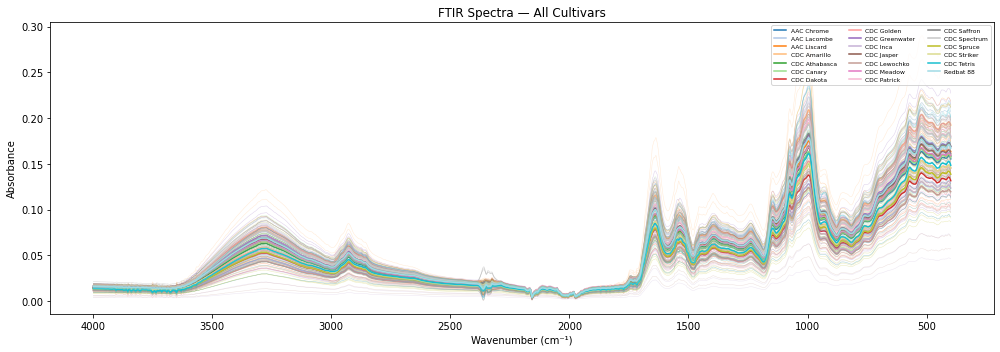

Total spectra: 180
Spectral points per spectrum: 2527


In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab20(np.linspace(0, 1, len(np.unique(sample_names))))
cultivar_list = np.unique(sample_names)

for i, cult in enumerate(cultivar_list):
    mask    = sample_names == cult
    spectra = X_ftir[mask]
    for spec in spectra:
        ax.plot(wavenumbers, spec, color=colors[i], alpha=0.3, linewidth=0.5)
    ax.plot(wavenumbers, spectra.mean(axis=0),
            color=colors[i], linewidth=1.5, label=cult)

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Absorbance")
ax.set_title("FTIR Spectra — All Cultivars")
ax.invert_xaxis()  # FTIR convention — wavenumber decreases left to right
ax.legend(fontsize=6, ncol=3, loc='upper right')
plt.tight_layout()
plt.savefig("FTIR_all_spectra.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Total spectra: {X_ftir.shape[0]}")
print(f"Spectral points per spectrum: {X_ftir.shape[1]}")

## Mean Spectrum per Cultivar

Plots one mean spectrum per cultivar to make it easier to compare between cultivars without the noise from individual spectra. This gives a cleaner view of the spectral differences between cultivars.

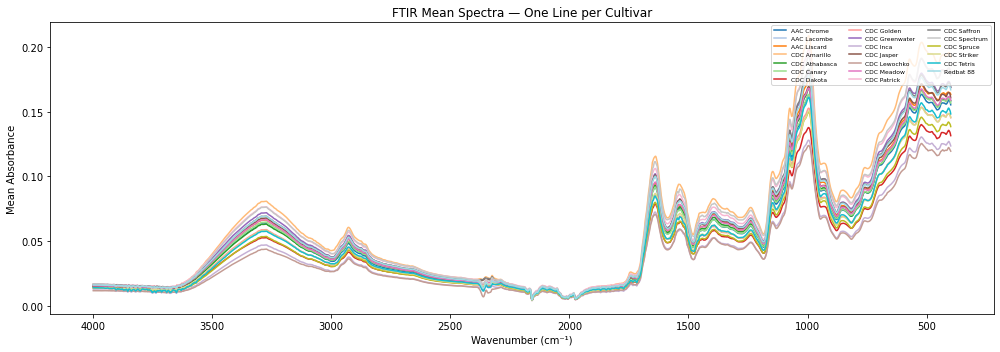

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

for i, cult in enumerate(cultivar_list):
    mask = sample_names == cult
    mean_spec = X_ftir[mask].mean(axis=0)
    ax.plot(wavenumbers, mean_spec, color=colors[i],
            linewidth=1.5, label=cult)

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Mean Absorbance")
ax.set_title("FTIR Mean Spectra — One Line per Cultivar")
ax.invert_xaxis()
ax.legend(fontsize=6, ncol=3, loc='upper right')
plt.tight_layout()
plt.savefig("FTIR_mean_spectra.png", dpi=150, bbox_inches='tight')
plt.show()

## Spectra Count per Cultivar per Location

Shows how many spectra are available for each cultivar at each growing location. This is important for understanding the data balance and whether LOCOCV will be feasible with this dataset.

In [18]:
print("Spectra count per cultivar per location:")
print("="*55)
print(f"{'Cultivar':<20} {'Limerick':>10} {'Rosthern':>10} {'Sutherland':>12} {'Total':>7}")
print("-"*55)

for cult in cultivar_list:
    mask = sample_names == cult
    locs = locations[mask]
    lim  = np.sum(locs == 'Limerick')
    ros  = np.sum(locs == 'Rosthern')
    sut  = np.sum(locs == 'Sutherland')
    tot  = lim + ros + sut
    print(f"{cult:<20} {lim:>10} {ros:>10} {sut:>12} {tot:>7}")

print("="*55)
print(f"{'Total':<20} {np.sum(locations=='Limerick'):>10} "
      f"{np.sum(locations=='Rosthern'):>10} "
      f"{np.sum(locations=='Sutherland'):>12} "
      f"{len(locations):>7}")

Spectra count per cultivar per location:
Cultivar               Limerick   Rosthern   Sutherland   Total
-------------------------------------------------------
AAC Chrome                    3          3            3       9
AAC Lacombe                   3          3            3       9
AAC Liscard                   3          3            3       9
CDC Amarillo                  3          3            3       9
CDC Athabasca                 3          3            3       9
CDC Canary                    3          3            3       9
CDC Dakota                    3          3            3       9
CDC Golden                    3          3            3       9
CDC Greenwater                3          3            3       9
CDC Inca                      3          3            3       9
CDC Jasper                    3          3            3       9
CDC Lewochko                  3          3            3       9
CDC Meadow                    3          3            3       9
CDC Pat

## Absorbance Distribution per Cultivar

Box plot showing the distribution of absorbance values across the full spectrum for each cultivar. This helps identify outlier spectra and understand the intensity variability within and between cultivars.

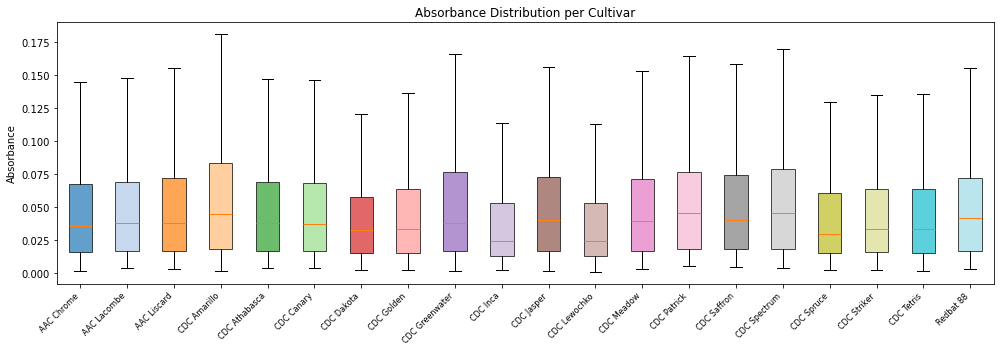

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

data_to_plot = [X_ftir[sample_names == cult].flatten()
                for cult in cultivar_list]

bp = ax.boxplot(data_to_plot, patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(cultivar_list) + 1))
ax.set_xticklabels(cultivar_list, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Absorbance")
ax.set_title("Absorbance Distribution per Cultivar")
plt.tight_layout()
plt.savefig("FTIR_absorbance_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## Within Cultivar Spectral Variability

Plots the standard deviation of spectra within each cultivar across the wavenumber range. High standard deviation at a particular wavenumber means high variability within that cultivar at that wavelength. Comparing this against between cultivar differences helps understand whether the spectral signal is strong enough for prediction.

fig, ax = plt.subplots(figsize=(14, 5))

for i, cult in enumerate(cultivar_list):
    mask    = sample_names == cult
    spectra = X_ftir[mask]
    std_spec = spectra.std(axis=0)
    ax.plot(wavenumbers, std_spec,
            color=colors[i], linewidth=1.0, label=cult, alpha=0.8)

ax.set_xlabel("Wavenumber (cm^-1)")
ax.set_ylabel("Standard Deviation of Absorbance")
ax.set_title("Within Cultivar Spectral Variability")
ax.invert_xaxis()
ax.legend(fontsize=6, ncol=3, loc='upper right')
plt.tight_layout()
plt.savefig("FTIR_within_cultivar_variability.png", dpi=150, bbox_inches='tight')
plt.show()

## Dataset Summary

Prints a complete summary of the FTIR dataset including dimensions, wavenumber range, cultivar count and absorbance statistics. Also lists key questions to discuss with Elham on Friday regarding the prediction target and modeling strategy.

In [22]:
print("=" * 55)
print("   FTIR DATASET SUMMARY")
print("=" * 55)
print(f"Total samples:          {X_ftir.shape[0]}")
print(f"Spectral data points:   {X_ftir.shape[1]}")
print(f"Wavenumber range:       {wavenumbers.min():.2f} to {wavenumbers.max():.2f} cm^-1")
print(f"Number of cultivars:    {len(cultivar_list)}")
print(f"Locations:              {np.unique(locations).tolist()}")
print(f"\nAbsorbance statistics:")
print(f"  Min:  {X_ftir.min():.5f}")
print(f"  Max:  {X_ftir.max():.5f}")
print(f"  Mean: {X_ftir.mean():.5f}")
print(f"  Std:  {X_ftir.std():.5f}")
print("=" * 55)

print("\nComparison with Raman dataset:")
print(f"  Raman spectral points: 1530")
print(f"  FTIR spectral points:  {X_ftir.shape[1]}")
print(f"  Raman total spectra:   6480")
print(f"  FTIR total spectra:    {X_ftir.shape[0]}")
print(f"  Raman spectra/cultivar: 324")
print(f"  FTIR spectra/cultivar:  {X_ftir.shape[0] // len(cultivar_list)}")


   FTIR DATASET SUMMARY
Total samples:          180
Spectral data points:   2527
Wavenumber range:       398.99 to 3998.44 cm^-1
Number of cultivars:    20
Locations:              ['Limerick', 'Rosthern', 'Sutherland']

Absorbance statistics:
  Min:  0.00075
  Max:  0.29002
  Mean: 0.05033
  Std:  0.04462

Comparison with Raman dataset:
  Raman spectral points: 1530
  FTIR spectral points:  2527
  Raman total spectra:   6480
  FTIR total spectra:    180
  Raman spectra/cultivar: 324
  FTIR spectra/cultivar:  9
